# Above and Beyond Context Content

Tests whether Design D hidden states predict the model's refusal decision **above and beyond
what the context text alone would predict**. If so, the representation encodes something
genuinely internal — not just a mirror of the input.

## Setup

**Target**: `is_refusal[T]` — did the model refuse at turn T?  
Design D captures the hidden state *before* generation at turn T, so this is truly predictive
(the state the model uses to produce the response).

**Feature sets compared**:

| Model | Features | What it controls for |
|-------|----------|---------------------|
| B1: depth | `n_context_turns` (scalar) | compliance accumulation |
| B2: question | TF-IDF of last user message | question topic/wording |
| B3: full context | TF-IDF of full conversation history | all text content |
| Probe | Hidden state at layer L | internal representation |
| Combined | Hidden state + `n_context_turns` | both |

## Within-group test (key result)

Group by `(pair_id, turn_idx)` — same objective, same turn position, different attempts.  
**Group-demean** all features: this removes between-group mean differences and tests only
within-group variation. Within a group, the question topic is roughly constant; what varies
is how much compliant context has accumulated (and correspondingly, the hidden state).

If group-demeaned hidden state AUC >> group-demeaned `n_context_turns` AUC, the
hidden state captures compliance history more precisely than the scalar count does.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

sns.set_theme(style="whitegrid", font_scale=1.1)
FIG_DIR = repo_root / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

LAYER_INDICES = [1, 16, 32]
LAYER_NAMES   = [f"Layer {l}" for l in LAYER_INDICES]
LAYER_COLORS  = ["#4e79a7", "#f28e2b", "#e15759"]
N_SPLITS      = 5

print("Imports OK")

Imports OK


## Load data

In [3]:
REPR_ROOT = repo_root / "data" / "representations"
# Conversation JSONs — from nb 01 (original) or nb 10 (faithful generation)
CONV_DIR  = repo_root / "data" / "conversations" / "crescendo_harmful_10_turns_clean"

# ── Load representations from nb 11 faithful extraction ───────────────────────
d = REPR_ROOT / "crescendo_harmful_10_turns_clean_faithful"
states_raw = np.load(str(d / "hidden_states.npy"), mmap_mode="r")
meta_raw   = pd.read_parquet(d / "metadata.parquet")

print(f"Loaded: {states_raw.shape}  ({len(meta_raw)} rows)")
print(f"Columns: {meta_raw.columns.tolist()}")

# ── Filter post-jailbreak turns (different generation regime) ─────────────────
if "is_post_jailbreak" in meta_raw.columns:
    keep = ~meta_raw["is_post_jailbreak"].fillna(False)
    n_drop = (~keep).sum()
    if n_drop > 0:
        print(f"Dropping {n_drop} post-jailbreak turns")
    meta_raw   = meta_raw[keep].reset_index(drop=True)
    states_raw = np.asarray(states_raw)[keep.values]

print(f"After filter: {len(meta_raw)} turns")
print(f"Refusal rate: {meta_raw['is_refusal'].mean():.1%}")
print(f"n_context_turns range: {meta_raw['n_context_turns'].min()}–{meta_raw['n_context_turns'].max()}")

Loaded: (9190, 3, 4096)  (9190 rows)
Columns: ['pair_id', 'attempt', 'turn_idx', 'is_refusal', 'n_context_turns', 'is_post_jailbreak', 'jailbreak_turn', 'final_verdict', 'label', 'framework', 'split', 'fname']
Dropping 1020 post-jailbreak turns
After filter: 8170 turns
Refusal rate: 82.8%
n_context_turns range: 0–9


## Load conversation text

Reconstruct the exact context text the model saw at each turn using the same
rollback-aware logic as notebook 11: only non-refusal pairs accumulate in context.

In [4]:
def extract_context_texts(conv_dir: Path, fnames) -> dict:
    """
    For each conversation file, reconstruct the context text per turn.
    Returns dict: (fname, turn_idx) -> {question_text, context_text}
    """
    result = {}
    missing = []

    for fname in set(fnames):
        fpath = conv_dir / fname
        if not fpath.exists():
            missing.append(fname)
            continue

        conv = json.loads(fpath.read_text())

        # Index turns by turn_idx
        by_idx = {}
        for t in conv["turns"]:
            by_idx.setdefault(t["turn_idx"], {})[t["role"]] = t

        accumulated = []  # non-refusal message pairs seen so far
        for turn_idx in sorted(by_idx):
            pair   = by_idx[turn_idx]
            user_t = pair.get("user")
            asst_t = pair.get("assistant")
            if not user_t or not asst_t:
                continue

            is_refusal = asst_t.get("is_refusal", False)
            question   = user_t["content"]

            # Full context = history + current question
            ctx_parts = [f"[{m['role'].upper()}] {m['content']}" for m in accumulated]
            ctx_parts.append(f"[USER] {question}")

            result[(fname, turn_idx)] = {
                "question_text": question,
                "context_text":  "\n".join(ctx_parts),
            }

            if not is_refusal:
                accumulated.append({"role": "user",      "content": question})
                accumulated.append({"role": "assistant", "content": asst_t["content"]})

    if missing:
        print(f"Warning: {len(missing)} JSON files not found in {conv_dir}")
    return result


print("Extracting context texts from conversation JSONs...")
text_lookup = extract_context_texts(CONV_DIR, meta_raw["fname"])
print(f"Extracted text for {len(text_lookup)} (fname, turn_idx) keys")

Extracting context texts from conversation JSONs...
Extracted text for 9190 (fname, turn_idx) keys


## Align representations and text features

In [5]:
# Add text columns to metadata
question_texts = []
context_texts  = []
keep_mask      = []

for _, row in meta_raw.iterrows():
    key = (row["fname"], row["turn_idx"])
    if key in text_lookup:
        question_texts.append(text_lookup[key]["question_text"])
        context_texts.append(text_lookup[key]["context_text"])
        keep_mask.append(True)
    else:
        keep_mask.append(False)

keep_mask = np.array(keep_mask)
meta      = meta_raw[keep_mask].reset_index(drop=True)
states    = np.asarray(states_raw)[keep_mask].astype(np.float32)

meta["question_text"] = question_texts
meta["context_text"]  = context_texts

# Target variable
y = meta["is_refusal"].astype(int).values

# Group identifier for within-group analysis
meta["group"] = meta["pair_id"].astype(str) + "_" + meta["turn_idx"].astype(str)
groups        = meta["group"].values

print(f"Final dataset: {len(meta)} turns  (dropped {keep_mask.size - keep_mask.sum()} missing text)")
print(f"States: {states.shape}")
print(f"Refusal rate: {y.mean():.1%}  ({y.sum()} refusal, {(y==0).sum()} non-refusal)")
print(f"Unique groups (pair_id × turn_idx): {meta['group'].nunique()}")

Final dataset: 8170 turns  (dropped 0 missing text)
States: (8170, 3, 4096)
Refusal rate: 82.8%  (6767 refusal, 1403 non-refusal)
Unique groups (pair_id × turn_idx): 984


## Probe helpers

In [6]:
def lr_cv(X: np.ndarray, y: np.ndarray, n_splits: int = N_SPLITS, C: float = 0.1) -> float:
    """Stratified k-fold logistic regression. Returns mean AUC."""
    if len(np.unique(y)) < 2 or len(y) < n_splits * 2:
        return float("nan")
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for tr, te in skf.split(X, y):
        sc   = StandardScaler()
        Xtr  = sc.fit_transform(X[tr])
        Xte  = sc.transform(X[te])
        clf  = LogisticRegression(max_iter=1000, C=C)
        clf.fit(Xtr, y[tr])
        aucs.append(roc_auc_score(y[te], clf.predict_proba(Xte)[:, 1]))
    return float(np.mean(aucs))


def tfidf_lr_cv(
    texts: list[str],
    y: np.ndarray,
    n_components: int = 200,
    n_splits: int = N_SPLITS,
    C: float = 0.1,
) -> float:
    """TF-IDF + SVD + LR pipeline with stratified k-fold CV. Returns mean AUC."""
    if len(np.unique(y)) < 2:
        return float("nan")
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=15000, ngram_range=(1, 2), sublinear_tf=True)),
        ("svd",   TruncatedSVD(n_components=min(n_components, len(texts) - 2), random_state=42)),
        ("lr",    LogisticRegression(max_iter=1000, C=C)),
    ])
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for tr, te in skf.split(np.zeros(len(y)), y):
        pipe.fit([texts[i] for i in tr], y[tr])
        aucs.append(roc_auc_score(y[te], pipe.predict_proba([texts[i] for i in te])[:, 1]))
    return float(np.mean(aucs))


def get_layer(states: np.ndarray, layer_pos: int) -> np.ndarray:
    return np.asarray(states[:, layer_pos, :], dtype=np.float32)


print("Helpers defined.")

Helpers defined.


## Baseline probes

Three content-only baselines — each knows only what is in the input text.

In [7]:
# B1: n_context_turns (scalar)
X_ncxt = meta["n_context_turns"].values.reshape(-1, 1).astype(np.float32)
auc_b1 = lr_cv(X_ncxt, y)
print(f"B1  n_context_turns only:    AUC = {auc_b1:.3f}")

# B2: TF-IDF of last user question
print("B2  TF-IDF (question only) — fitting...")
auc_b2 = tfidf_lr_cv(list(meta["question_text"]), y)
print(f"B2  TF-IDF (question only):  AUC = {auc_b2:.3f}")

# B3: TF-IDF of full context (history + question)
print("B3  TF-IDF (full context)  — fitting...")
auc_b3 = tfidf_lr_cv(list(meta["context_text"]), y)
print(f"B3  TF-IDF (full context):   AUC = {auc_b3:.3f}")

B1  n_context_turns only:    AUC = 0.770
B2  TF-IDF (question only) — fitting...
B2  TF-IDF (question only):  AUC = 0.804
B3  TF-IDF (full context)  — fitting...
B3  TF-IDF (full context):   AUC = 0.853


## Hidden state probes

In [8]:
hs_aucs = {}
for li, lname in enumerate(LAYER_NAMES):
    X = get_layer(states, li)
    auc = lr_cv(X, y)
    hs_aucs[lname] = auc
    print(f"Hidden state {lname}:          AUC = {auc:.3f}")

best_layer_pos  = int(np.argmax([hs_aucs[l] for l in LAYER_NAMES]))
best_layer_name = LAYER_NAMES[best_layer_pos]
print(f"\nBest layer: {best_layer_name}  (AUC = {hs_aucs[best_layer_name]:.3f})")

Hidden state Layer 1:          AUC = 0.841
Hidden state Layer 16:          AUC = 0.878
Hidden state Layer 32:          AUC = 0.885

Best layer: Layer 32  (AUC = 0.885)


## Combined probes

Does adding hidden state to the content baseline improve AUC?

In [9]:
X_best_hs = get_layer(states, best_layer_pos)

# Hidden state + n_context_turns
sc_hs = StandardScaler().fit(X_best_hs)
sc_nc = StandardScaler().fit(X_ncxt)
X_combined_nc  = np.hstack([sc_hs.transform(X_best_hs), sc_nc.transform(X_ncxt)])
auc_combined_nc = lr_cv(X_combined_nc, y)
print(f"Hidden state + n_context_turns: AUC = {auc_combined_nc:.3f}")

# n_context_turns gain from adding hidden state
delta_nc = auc_combined_nc - auc_b1
print(f"  Δ over B1 (n_context_turns alone): +{delta_nc:.3f}")

# Hidden state gain over best content baseline
best_content_auc = max(auc_b1, auc_b2, auc_b3)
delta_content = hs_aucs[best_layer_name] - best_content_auc
print(f"\nHidden state ({best_layer_name}) vs best content baseline: {delta_content:+.3f}")

Hidden state + n_context_turns: AUC = 0.885
  Δ over B1 (n_context_turns alone): +0.115

Hidden state (Layer 32) vs best content baseline: +0.032


## Comparison figure

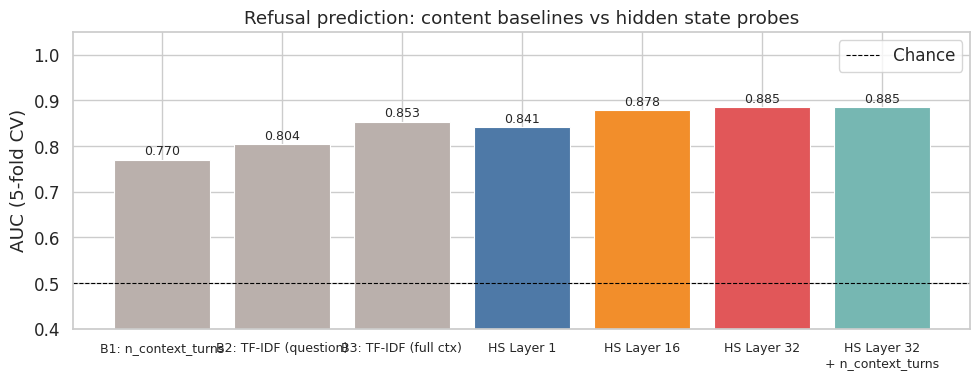

In [10]:
labels = [
    "B1: n_context_turns",
    "B2: TF-IDF (question)",
    "B3: TF-IDF (full ctx)",
] + [f"HS {n}" for n in LAYER_NAMES] + [
    f"HS {best_layer_name}\n+ n_context_turns",
]

aucs = [
    auc_b1, auc_b2, auc_b3,
] + [hs_aucs[n] for n in LAYER_NAMES] + [
    auc_combined_nc,
]

colors = (
    ["#bab0ac"] * 3          # baselines: gray
    + LAYER_COLORS            # hidden state per layer
    + ["#76b7b2"]             # combined: teal
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, aucs, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="Chance")
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f"{auc:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("AUC (5-fold CV)")
ax.set_title("Refusal prediction: content baselines vs hidden state probes")
ax.set_ylim(0.4, 1.05)
ax.tick_params(axis="x", labelsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "above_beyond_comparison.png", dpi=150)
plt.show()

## Within-group (fixed-effects) analysis

Group by `(pair_id, turn_idx)` — same objective at the same turn position across attempts.
**Group-demean** each feature: subtract the group mean. This removes between-group variation
(different topics are harder/easier) and tests only *within-group* variation.

Within a group:
- Question topic is roughly constant (same objective, same turn position)
- `n_context_turns` varies (depends on whether earlier turns were refused)
- Hidden state varies (different compliance context → different representation)

**Interpretation**: if group-demeaned hidden state AUC >> group-demeaned `n_context_turns` AUC,
the hidden state captures the compliance history signal more precisely than the integer count.

In [11]:
def group_demean(X: np.ndarray, groups: np.ndarray) -> np.ndarray:
    """Subtract group mean from each row."""
    X_dm = X.copy().astype(np.float32)
    for g in np.unique(groups):
        mask = groups == g
        X_dm[mask] -= X_dm[mask].mean(0)
    return X_dm


# Only use groups with at least 1 refusal and 1 non-refusal
grp_has_both = (
    meta.groupby("group")["is_refusal"]
    .apply(lambda s: s.any() and (~s).any())
)
valid_groups = grp_has_both[grp_has_both].index
mask_wg      = meta["group"].isin(valid_groups).values

print(f"Groups with mixed outcomes: {len(valid_groups)} / {meta['group'].nunique()}")
print(f"Turns in those groups:      {mask_wg.sum()}")

y_wg      = y[mask_wg]
groups_wg = groups[mask_wg]

# Group-demean n_context_turns
X_ncxt_dm = group_demean(X_ncxt[mask_wg], groups_wg)
auc_wg_b1 = lr_cv(X_ncxt_dm, y_wg)
print(f"\nWithin-group B1 (n_context_turns):  AUC = {auc_wg_b1:.3f}")

# Group-demean hidden state (best layer)
X_hs_best_dm = group_demean(X_best_hs[mask_wg], groups_wg)
auc_wg_hs    = lr_cv(X_hs_best_dm, y_wg)
print(f"Within-group HS ({best_layer_name}):     AUC = {auc_wg_hs:.3f}")

# All layers
wg_hs_aucs = {}
for li, lname in enumerate(LAYER_NAMES):
    X_dm = group_demean(get_layer(states[mask_wg], li), groups_wg)
    wg_hs_aucs[lname] = lr_cv(X_dm, y_wg)
    print(f"Within-group HS {lname}:             AUC = {wg_hs_aucs[lname]:.3f}")

Groups with mixed outcomes: 480 / 984
Turns in those groups:      3917

Within-group B1 (n_context_turns):  AUC = 0.594
Within-group HS (Layer 32):     AUC = 0.641
Within-group HS Layer 1:             AUC = 0.575
Within-group HS Layer 16:             AUC = 0.645
Within-group HS Layer 32:             AUC = 0.641


## Within-group figure

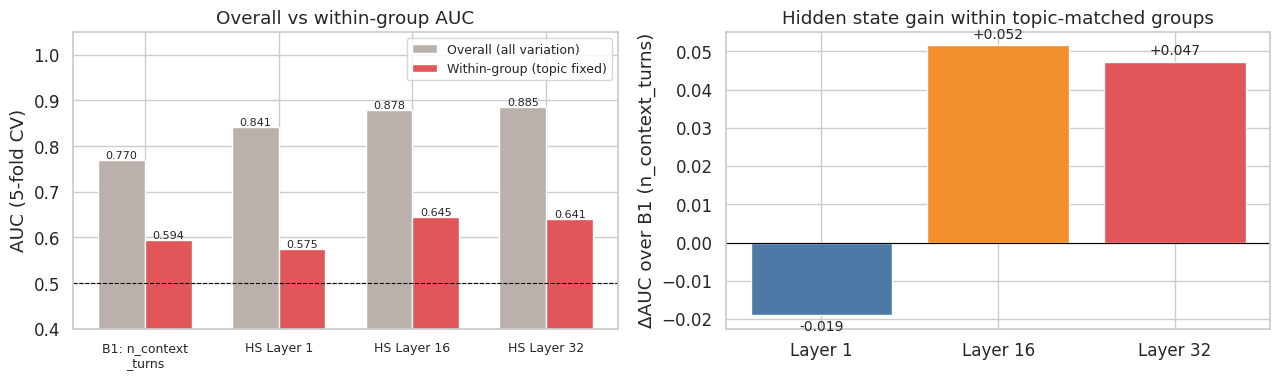

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: overall vs within-group AUC comparison ─────────────────────────────
ax = axes[0]
model_labels = ["B1: n_context\n_turns"] + [f"HS {n}" for n in LAYER_NAMES]
overall_aucs = [auc_b1] + [hs_aucs[n] for n in LAYER_NAMES]
wg_aucs      = [auc_wg_b1] + [wg_hs_aucs[n] for n in LAYER_NAMES]

x     = np.arange(len(model_labels))
width = 0.35
ax.bar(x - width/2, overall_aucs, width, label="Overall (all variation)",   color="#bab0ac", edgecolor="white")
ax.bar(x + width/2, wg_aucs,      width, label="Within-group (topic fixed)", color="#e15759", edgecolor="white")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylabel("AUC (5-fold CV)")
ax.set_title("Overall vs within-group AUC")
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=9)

for i, (o, w) in enumerate(zip(overall_aucs, wg_aucs)):
    ax.text(i - width/2, o + 0.003, f"{o:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, w + 0.003, f"{w:.3f}", ha="center", fontsize=8)

# ── Right: AUC gain (HS vs B1) within groups ─────────────────────────────────
ax = axes[1]
wg_deltas = [wg_hs_aucs[n] - auc_wg_b1 for n in LAYER_NAMES]
bars = ax.bar(LAYER_NAMES, wg_deltas, color=LAYER_COLORS, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
for bar, delta in zip(bars, wg_deltas):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001 * np.sign(delta),
            f"{delta:+.3f}", ha="center", va="bottom" if delta >= 0 else "top", fontsize=10)
ax.set_ylabel("ΔAUC over B1 (n_context_turns)")
ax.set_title("Hidden state gain within topic-matched groups")

plt.tight_layout()
plt.savefig(FIG_DIR / "above_beyond_within_group.png", dpi=150)
plt.show()

## Matched-pair concordance

For each group with mixed outcomes, form all (refusal attempt, non-refusal attempt) pairs.
Check whether the feature score correctly ranks the refusal attempt higher (for hidden state)
or lower (for `n_context_turns`, which decreases refusal rate).

Concordance > 0.5 means the feature discriminates within topic-matched groups.

In [13]:
def matched_concordance(scores: np.ndarray, y: np.ndarray, groups: np.ndarray,
                        higher_is_refusal: bool = True) -> tuple[float, int]:
    """
    Within each group, count pairs (refusal, non-refusal) where the score
    correctly ranks the refusal turn. Returns (concordance_rate, n_pairs).
    """
    concordant = 0
    total      = 0
    for g in np.unique(groups):
        mask = groups == g
        y_g  = y[mask]
        s_g  = scores[mask]
        ref_scores    = s_g[y_g == 1]
        nonref_scores = s_g[y_g == 0]
        if len(ref_scores) == 0 or len(nonref_scores) == 0:
            continue
        for r in ref_scores:
            for nr in nonref_scores:
                total += 1
                if higher_is_refusal:
                    concordant += int(r > nr)
                else:
                    concordant += int(r < nr)
    return (concordant / total if total > 0 else float("nan")), total


# Train LAT refusal vector on all data (refusal vs non-refusal)
X_hs_best_all = get_layer(states, best_layer_pos)
sc_all        = StandardScaler().fit(X_hs_best_all)
X_hs_scaled   = sc_all.transform(X_hs_best_all)
lat_refusal   = X_hs_scaled[y == 1].mean(0) - X_hs_scaled[y == 0].mean(0)
lat_refusal  /= np.linalg.norm(lat_refusal) + 1e-8

lat_scores = X_hs_scaled @ lat_refusal   # higher = more refusal-like

# Concordance: LAT score
conc_hs,  n_pairs = matched_concordance(lat_scores[mask_wg], y_wg, groups_wg, higher_is_refusal=True)

# Concordance: n_context_turns (higher = fewer refusals → lower concordance expected)
ncxt_scores = X_ncxt[:, 0]
conc_ncxt, _      = matched_concordance(ncxt_scores[mask_wg], y_wg, groups_wg, higher_is_refusal=False)

print(f"Matched pairs (within topic-matched groups): {n_pairs:,}")
print()
print(f"n_context_turns concordance:        {conc_ncxt:.3f}  (correct if refusal turns have fewer context turns)")
print(f"LAT score concordance ({best_layer_name}): {conc_hs:.3f}  (correct if refusal turns have higher LAT score)")
print()
print("Interpretation:")
print(f"  Chance = 0.500")
print(f"  n_context_turns: {conc_ncxt - 0.5:+.3f} above chance")
print(f"  Hidden state:    {conc_hs - 0.5:+.3f} above chance")

Matched pairs (within topic-matched groups): 5,483

n_context_turns concordance:        0.357  (correct if refusal turns have fewer context turns)
LAT score concordance (Layer 32): 0.737  (correct if refusal turns have higher LAT score)

Interpretation:
  Chance = 0.500
  n_context_turns: -0.143 above chance
  Hidden state:    +0.237 above chance


## Scatter: n_context_turns vs LAT score, coloured by is_refusal

Visualises the separation added by the hidden state beyond what `n_context_turns` alone provides.

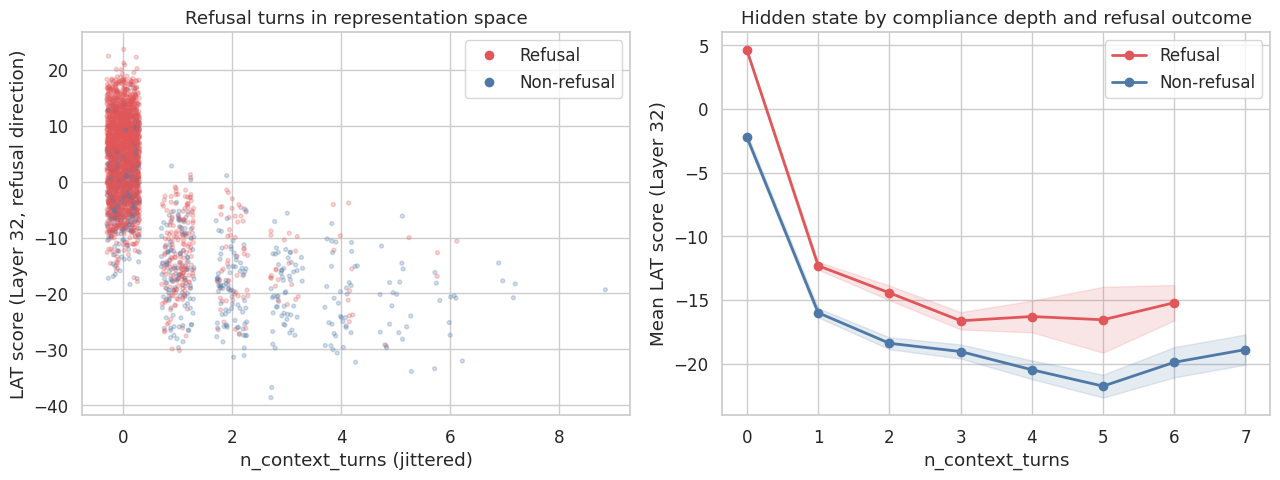

AUC at each n_context_turns level (hidden state only):
  n_context_turns= 0:  n=6505  refusal_rate=0.92  AUC=0.840
  n_context_turns= 1:  n= 864  refusal_rate=0.59  AUC=0.728
  n_context_turns= 2:  n= 367  refusal_rate=0.43  AUC=0.720
  n_context_turns= 3:  n= 209  refusal_rate=0.34  AUC=0.659
  n_context_turns= 4:  n= 116  refusal_rate=0.22  AUC=0.598
  n_context_turns= 5:  n=  54  refusal_rate=0.15  AUC=0.613
  n_context_turns= 6:  n=  35  refusal_rate=0.20  AUC=0.540


In [14]:
# Sample up to 3000 points for readability
rng    = np.random.default_rng(42)
n_show = min(3000, len(meta))
idx    = rng.choice(len(meta), n_show, replace=False)

x_jit = meta["n_context_turns"].values[idx] + rng.uniform(-0.3, 0.3, n_show)
y_jit = lat_scores[idx]
c_jit = ["#e15759" if r else "#4e79a7" for r in y[idx]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: scatter ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(x_jit, y_jit, c=c_jit, alpha=0.25, s=8, rasterized=True)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#e15759", markersize=8, label="Refusal"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4e79a7", markersize=8, label="Non-refusal"),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("n_context_turns (jittered)")
ax.set_ylabel(f"LAT score ({best_layer_name}, refusal direction)")
ax.set_title("Refusal turns in representation space")

# ── Right: mean LAT score by (n_context_turns, is_refusal) ───────────────────
ax = axes[1]
df_plot = meta[["n_context_turns", "is_refusal"]].copy()
df_plot["lat"] = lat_scores
for is_ref, label, color in [(True, "Refusal", "#e15759"), (False, "Non-refusal", "#4e79a7")]:
    sub  = df_plot[df_plot.is_refusal == is_ref].groupby("n_context_turns")["lat"].agg(["mean", "sem", "count"])
    sub  = sub[sub["count"] >= 5]
    ax.plot(sub.index, sub["mean"], marker="o", color=color, label=label, linewidth=2)
    ax.fill_between(sub.index, sub["mean"] - sub["sem"],
                    sub["mean"] + sub["sem"], color=color, alpha=0.15)
ax.set_xlabel("n_context_turns")
ax.set_ylabel(f"Mean LAT score ({best_layer_name})")
ax.set_title("Hidden state by compliance depth and refusal outcome")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(FIG_DIR / "above_beyond_scatter.png", dpi=150)
plt.show()

# Also: at a fixed n_context_turns, how well does the LAT score predict refusal?
print("AUC at each n_context_turns level (hidden state only):")
for ncxt in sorted(meta["n_context_turns"].unique()):
    mask_nc = meta["n_context_turns"].values == ncxt
    y_nc = y[mask_nc]
    if y_nc.sum() < 5 or (y_nc == 0).sum() < 5:
        continue
    X_nc = get_layer(states[mask_nc], best_layer_pos)
    auc  = lr_cv(X_nc, y_nc)
    print(f"  n_context_turns={ncxt:2d}:  n={mask_nc.sum():4d}  refusal_rate={y_nc.mean():.2f}  AUC={auc:.3f}")

## Summary

| Model | AUC (overall) | AUC (within-group) | Δ over B1 (within) |
|-------|--------------|-------------------|--------------------|
| B1: n_context_turns | — | — | 0 |
| B2: TF-IDF (question) | — | — | — |
| B3: TF-IDF (full ctx) | — | — | — |
| HS Layer 1 | — | — | — |
| HS Layer 16 | — | — | — |
| HS Layer 32 | — | — | — |

*(Fill in after running.)*

**If hidden state within-group AUC >> n_context_turns within-group AUC**: the model's
representation captures the compliance accumulation signal more precisely than the
scalar turn count — evidence of a genuinely graded internal state, not just turn counting.

**If hidden state AUC ≈ full-context TF-IDF AUC**: the signal is in the literal text
content and the hidden state is just efficiently compressing it.

**If hidden state AUC >> full-context TF-IDF AUC**: the representation encodes something
that is not recoverable from bag-of-words text features — a stronger claim about internal
state.